# 07 · Anomalies and market regimes

**Questions.** (1) Do a machine-learning anomaly detector and two statistical rules flag the same days, and what do the flagged days look like when inspected by hand? (2) How did volatility and correlation differ between calm and turbulent markets?

All results are read from the stored Data Science Lab run (`python scripts/run_ml.py`); nothing is retrained here. A flag means *Potential data anomaly detected*: a reason to look at a data point, never a statement about a company.

*FinSight is an analytics tool, not investment advice.*

## 1. Data

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from src.database import queries
from src.database.connection import get_engine

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})
ACCENT, GREY = "#1f4e79", "#8c8c8c"

with get_engine().connect() as conn:
    companies = queries.load_companies(conn)
    prices = queries.load_prices_ohlc(conn)
    statements = queries.load_statements(conn)
    metrics = queries.load_metrics(conn)
    quality = pd.read_sql(text("""SELECT * FROM core.data_quality_summary
                                  ORDER BY run_id DESC LIMIT 1"""), conn).iloc[0]
print(f"{len(companies) - 1} companies + benchmark | {len(prices):,} price rows | "
      f"{len(statements):,} statement rows | {len(metrics):,} metric rows")

with get_engine().connect() as conn:
    runs = pd.read_sql(text("SELECT task, seed, data_snapshot_id, params, results FROM core.ml_runs"),
                       conn).set_index("task")
    flags = pd.read_sql(text("""SELECT c.ticker, f.* FROM core.ml_anomaly_flags f
                                JOIN core.companies c USING (company_id)"""), conn)
    regimes = pd.read_sql(text("SELECT * FROM core.ml_regimes ORDER BY date"), conn)
anomaly_run, regime_run = runs.loc["anomaly_comparison"], runs.loc["regimes"]
print(f"Anomaly run: seed {anomaly_run['seed']}, snapshot {anomaly_run['data_snapshot_id']}, "
      f"{anomaly_run['results']['summary']['observations']:,} company-days examined.")

25 companies + benchmark | 32,243 price rows | 7,347 statement rows | 6,146 metric rows
Anomaly run: seed 42, snapshot 2dca6b196267, 31,258 company-days examined.


## 2. Method

- **IQR**: return or log volume outside 3×IQR fences of the stock's previous 60 days.
- **Modified z-score**: |0.6745 × (x − median) / MAD| > 3.5 against the previous 60 days.
- **Isolation Forest**: 200 trees on the same rolling scores, contamination fixed at 2% in advance.

There are no labels, so the comparison is agreement, not accuracy.

## 3. Results

### 3.1 How far the methods agree

In [2]:
summary = anomaly_run["results"]["summary"]
overlap = pd.DataFrame(anomaly_run["results"]["overlap"])
counts = pd.Series(summary["flagged_by"], name="flagged")
print(pd.DataFrame({"flagged": counts,
                    "share of observations (%)": counts / summary["observations"] * 100}).round(2))
print()
print(overlap.round(3).to_string(index=False))
print(f"\nFlagged by all three: {summary['flagged_by_all_three']}; by exactly two: "
      f"{summary['flagged_by_exactly_two']}; by exactly one: {summary['flagged_by_exactly_one']}; "
      f"by the Isolation Forest alone: {summary['isolation_forest_only']}.")
flags.groupby("methods_agreeing").agg(days=("date", "size"),
                                      median_abs_return=("daily_return", lambda s: s.abs().median()),
                                      median_abs_volume_score=("volume_score", lambda s: s.abs().median()))

                  flagged  share of observations (%)
iqr                   336                     1.0700
modified_zscore       918                     2.9400
isolation_forest      626                     2.0000

 both  only_a  only_b  jaccard        method_a         method_b
  336       0     582   0.3660             iqr  modified_zscore
  262      74     364   0.3740             iqr isolation_forest
  528     390      98   0.5200 modified_zscore isolation_forest

Flagged by all three: 262; by exactly two: 340; by exactly one: 414; by the Isolation Forest alone: 98.


,days,median_abs_return,median_abs_volume_score
methods_agreeing,,,
1,414,0.0302,2.4155
2,340,0.0402,3.4125
3,262,0.0532,3.5505


### 3.2 Manual inspection of flagged cases

The ten highest-scoring company-days flagged by all three methods, with the price and volume around each, to judge whether they look like data errors or real market moves.

In [3]:
top = (flags[flags["methods_agreeing"] == 3].sort_values("isolation_score", ascending=False)
       .head(10).reset_index(drop=True))
traded = prices[~prices["is_stale_quote"]]
rows = []
for case in top.itertuples():
    history = traded[traded["ticker"] == case.ticker].sort_values("date").reset_index(drop=True)
    i = history.index[history["date"] == case.date][0]
    before, day, after = history.iloc[i - 1], history.iloc[i], history.iloc[min(i + 1, len(history) - 1)]
    typical_volume = history.iloc[max(0, i - 60):i]["volume"].median()
    rows.append({
        "ticker": case.ticker.replace(".NS", ""), "date": case.date,
        "return": f"{case.daily_return:+.1%}",
        "close before": round(before["close"], 1), "close": round(day["close"], 1),
        "next-day return": f"{after['adj_close'] / day['adj_close'] - 1:+.1%}",
        "volume / 60d median": round(day["volume"] / typical_volume, 1) if typical_volume else None,
        "same-day flags (all tickers)": int((flags["date"] == case.date).sum()),
        "close within day range": bool(day["low"] <= day["close"] <= day["high"]),
    })
inspection = pd.DataFrame(rows)
inspection

,ticker,date,return,close before,close,next-day return,volume / 60d median,same-day flags (all tickers),close within day range
0,CIPLA,2023-07-27,+9.6%,"1,068.5000","1,171.4000",+0.5%,9.7000,4,True
1,MARUTI,2025-08-18,+8.8%,"12,936.0000","14,068.0000",+1.3%,8.2000,6,True
2,CIPLA,2024-10-31,+9.4%,"1,418.2000","1,551.8000",+0.5%,12.6000,3,True
3,BRITANNIA,2022-11-07,+8.8%,"3,804.2000","4,139.2000",+0.9%,11.2000,3,True
4,KOTAKBANK,2025-01-20,+9.2%,351.7000,384.1000,-1.4%,3.8000,2,True
5,ITC,2026-01-01,-9.7%,403.0000,363.9000,-3.8%,29.1000,2,True
6,HDFCBANK,2022-04-04,+10.0%,753.0000,828.4000,-2.9%,6.8000,1,True
7,DRREDDY,2026-04-23,+9.4%,"1,217.0000","1,331.0000",-1.0%,9.9000,2,True
8,KOTAKBANK,2024-04-25,-10.9%,368.6000,328.5000,-2.1%,14.8000,5,True
9,HCLTECH,2026-04-22,-10.8%,"1,441.2000","1,285.3000",-0.6%,11.9000,4,True


In [4]:
reversed_next_day = sum(
    (float(r["return"].rstrip("%")) * float(r["next-day return"].rstrip("%")) < 0)
    and abs(float(r["next-day return"].rstrip("%"))) > 0.5 * abs(float(r["return"].rstrip("%")))
    for r in rows)
print(f"Of these {len(rows)} cases: {int(inspection['close within day range'].sum())} have a "
      f"close inside the day's high-low range (internally consistent prices); "
      f"{int((inspection['volume / 60d median'] > 2).sum())} came with more than twice the usual "
      f"volume; {int((inspection['same-day flags (all tickers)'] > 3).sum())} fall on dates when "
      f"more than three company-days were flagged; {reversed_next_day} were more than half "
      "reversed the next day (the pattern a bad price tick would leave).")

Of these 10 cases: 10 have a close inside the day's high-low range (internally consistent prices); 10 came with more than twice the usual volume; 4 fall on dates when more than three company-days were flagged; 0 were more than half reversed the next day (the pattern a bad price tick would leave).


### 3.3 Market regimes (descriptive)

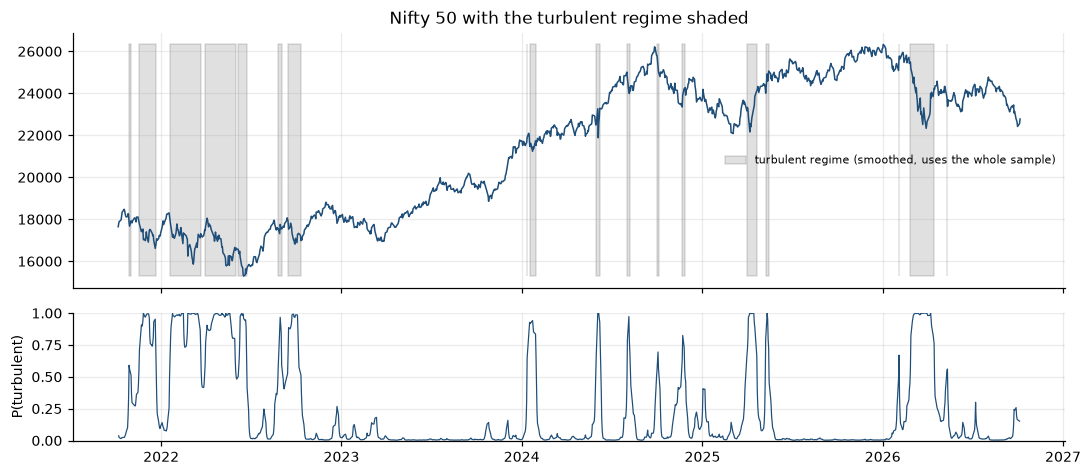

Estimated annualized volatility: calm 10.2%, turbulent 22.4%. Expected duration: calm 45 days, turbulent 13 days. 18.9% of days are turbulent. Agreement with the simple rolling-volatility rule: 85.2% of days.


days  share_of_days  market_volatility  mean_stock_volatility  mean_pairwise_correlation
                 regime                                                                                             
Markov switching calm        990         0.8108             0.1013                 0.2158                     0.1713
                 turbulent   231         0.1892             0.2386                 0.3035                     0.4107
threshold rule   calm        901         0.7379             0.1104                 0.2181                     0.1908
                 turbulent   300         0.2457             0.2013                 0.2766                     0.3600

In [5]:
result = regime_run["results"]
by_regime = pd.DataFrame(result["by_regime"]).set_index("regime")
by_rule = pd.DataFrame(result["by_threshold_regime"]).set_index("regime")
nifty = (prices[(prices["ticker"] == "^NSEI") & ~prices["is_stale_quote"]]
         .assign(date=lambda d: pd.to_datetime(d["date"])).set_index("date")["adj_close"])
regimes["date"] = pd.to_datetime(regimes["date"])
fig, axes = plt.subplots(2, 1, figsize=(10, 4.4), sharex=True, height_ratios=[2, 1])
axes[0].plot(nifty.index, nifty, color=ACCENT, lw=1)
turbulent = regimes.set_index("date")["regime"].reindex(nifty.index).fillna(0).to_numpy() == 1
axes[0].fill_between(nifty.index, nifty.min(), nifty.max(), where=turbulent, color="black",
                     alpha=0.12, label="turbulent regime (smoothed, uses the whole sample)")
axes[0].set_title("Nifty 50 with the turbulent regime shaded"); axes[0].legend(frameon=False, fontsize=7)
axes[1].plot(regimes["date"], regimes["p_turbulent"], color=ACCENT, lw=0.8)
axes[1].set_ylabel("P(turbulent)"); axes[1].set_ylim(0, 1); plt.tight_layout(); plt.show()
s = result["summary"]
print(f"Estimated annualized volatility: calm {s['volatility']['calm']:.1%}, turbulent "
      f"{s['volatility']['turbulent']:.1%}. Expected duration: calm "
      f"{s['expected_duration_days']['calm']:.0f} days, turbulent "
      f"{s['expected_duration_days']['turbulent']:.0f} days. "
      f"{s['turbulent_share_of_days']:.1%} of days are turbulent. Agreement with the simple "
      f"rolling-volatility rule: {s['agreement_with_threshold_rule']:.1%} of days.")
pd.concat({"Markov switching": by_regime, "threshold rule": by_rule})

## 4. Interpretation

- The three methods overlap substantially but not completely; the printed counts show how many days each flags and how many all three share. The Isolation Forest's count is set by its contamination parameter, so only *which* days it picks is informative.
- The manual inspection table is the evidence on what the strongest flags are. Read it row by row: a close inside the day's range, unusual volume, other companies flagged the same day, and no next-day reversal all point to a real market move rather than a bad data point. The summary line counts each of those properties.
- In the turbulent regime both volatility and average pairwise correlation are higher than in the calm regime, by the amounts in the table. Diversification across these stocks was weaker when it was needed most.

## 5. Limitations

- No ground truth: neither the anomaly flags nor the regimes can be scored for accuracy.
- The Isolation Forest and the regime model are fitted on the whole sample. The regime labels use information from after each date and **are not a trading signal**.
- Ten cases inspected by hand is a sample, not an audit; no news source was consulted, so 'real move' here means only that the data are internally consistent.
- Correlation estimates rise with volatility for mechanical reasons, so part of the regime difference in correlation is an artefact of measurement.

*FinSight is an analytics tool, not investment advice.*